Shape: (31, 19)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  


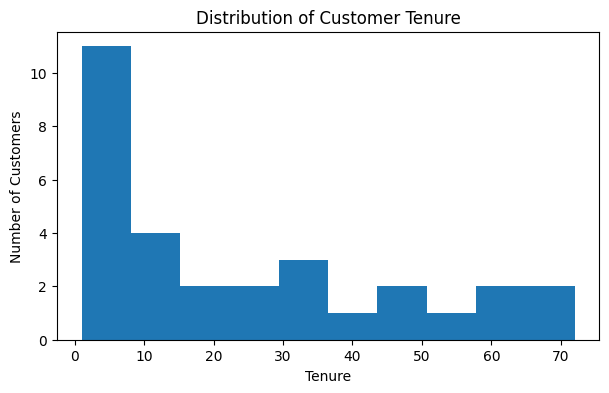

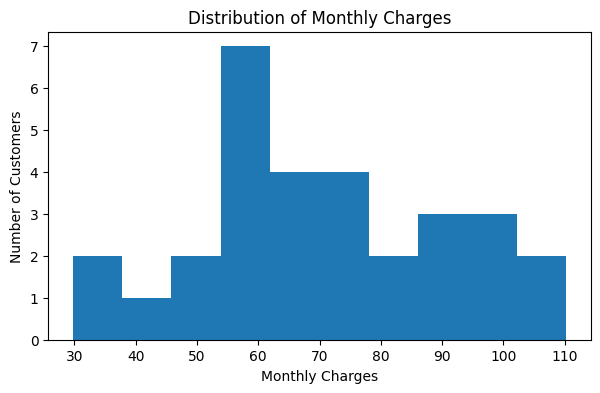

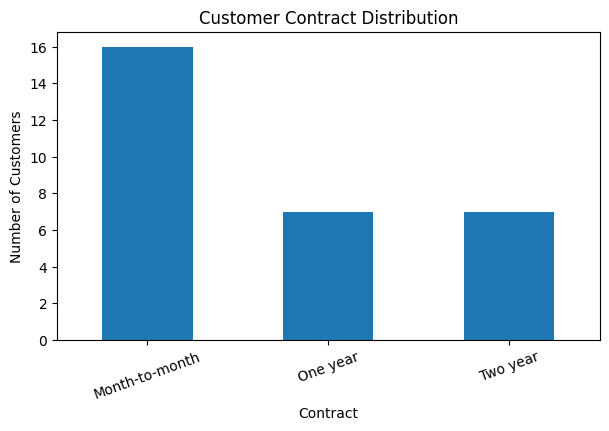

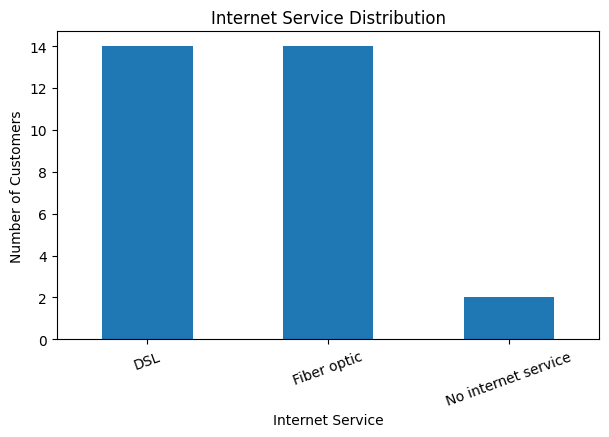

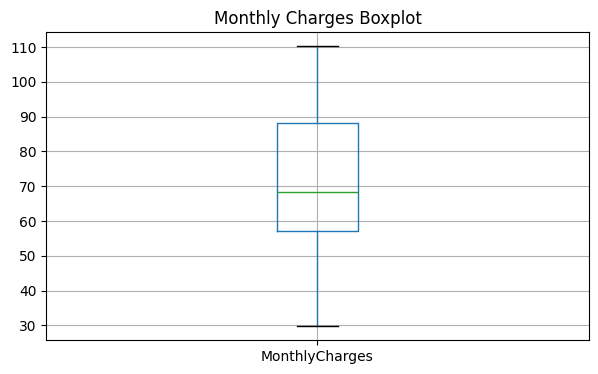

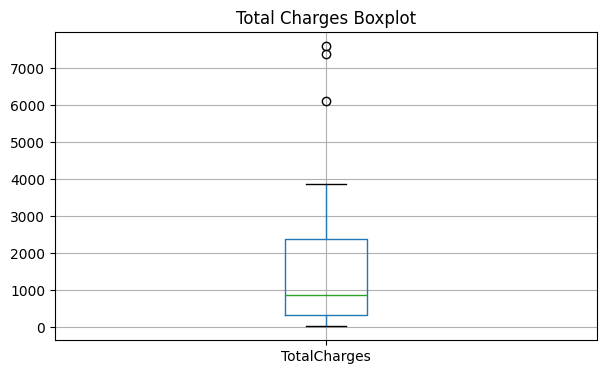

Churn
No     17
Yes    13
Name: count, dtype: int64
Churn
No     56.67
Yes    43.33
Name: proportion, dtype: float64


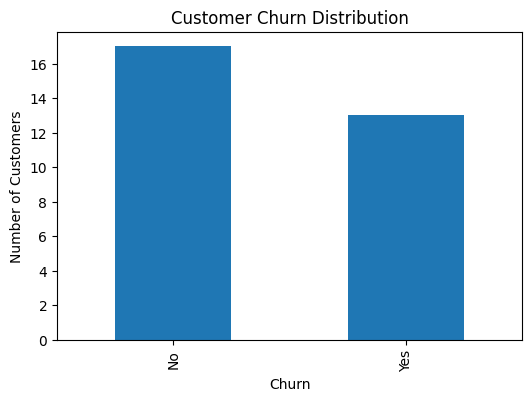

Churn               No    Yes
Contract                     
Month-to-month   18.75  81.25
One year        100.00   0.00
Two year        100.00   0.00


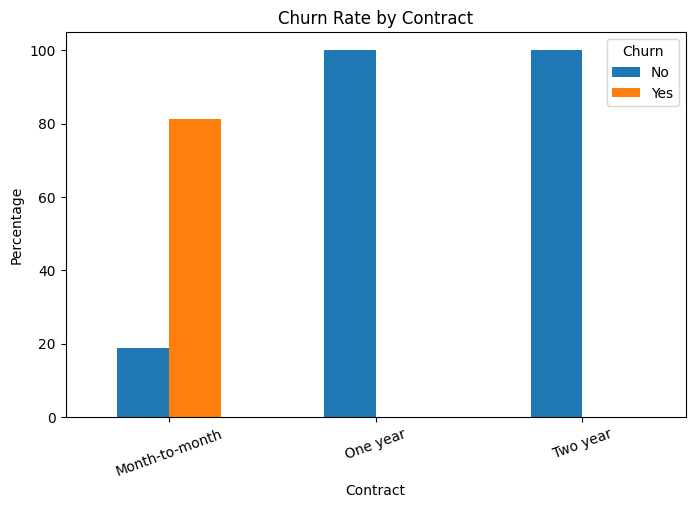

Churn                    No    Yes
InternetService                   
DSL                   71.43  28.57
Fiber optic           35.71  64.29
No internet service  100.00   0.00


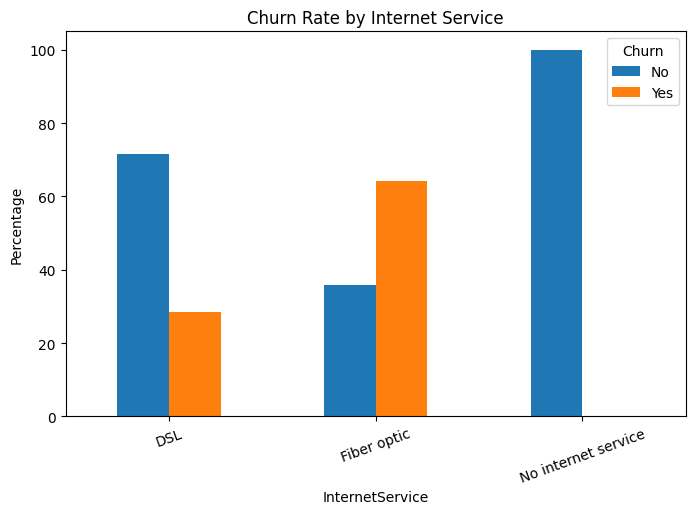

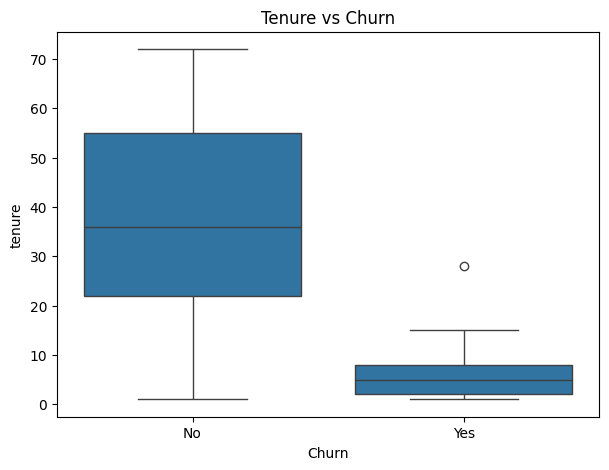

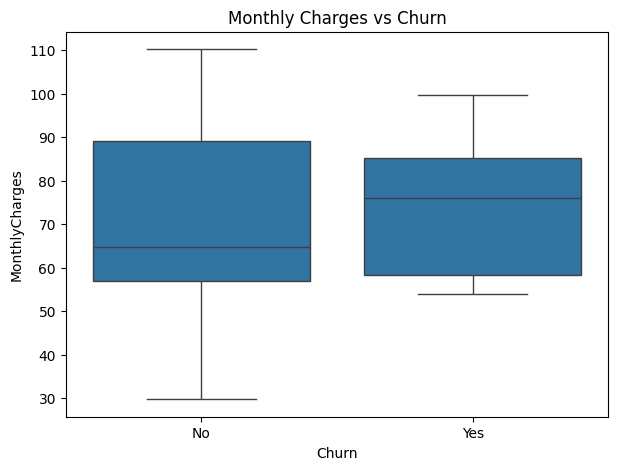

                SeniorCitizen  tenure  MonthlyCharges  TotalCharges
SeniorCitizen            1.00   -0.24            0.23         -0.17
tenure                  -0.24    1.00            0.30          0.92
MonthlyCharges           0.23    0.30            1.00          0.54
TotalCharges            -0.17    0.92            0.54          1.00


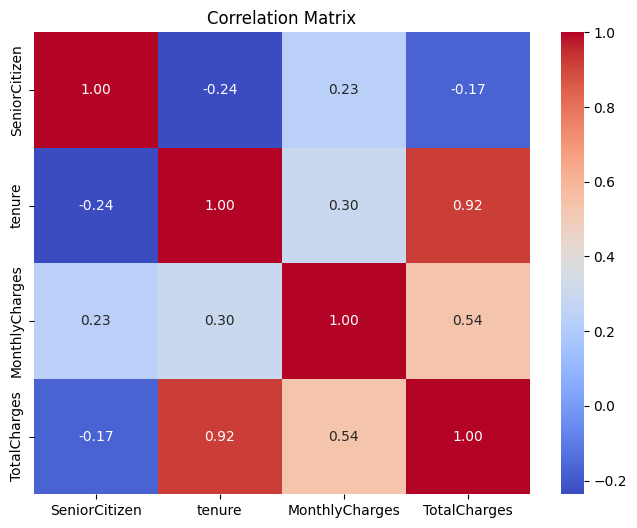

          Column    Type       Role Action                        Reason
      customerID  object Identifier Remove Only identifies the customer.
          gender  object    Feature   Keep      Categorical information.
   SeniorCitizen   int64    Feature   Keep        Numerical information.
         Partner  object    Feature   Keep      Categorical information.
      Dependents  object    Feature   Keep      Categorical information.
          tenure   int64    Feature   Keep        Numerical information.
    PhoneService  object    Feature   Keep      Categorical information.
 InternetService  object    Feature   Keep      Categorical information.
  OnlineSecurity  object    Feature   Keep      Categorical information.
    OnlineBackup  object    Feature   Keep      Categorical information.
DeviceProtection  object    Feature   Keep      Categorical information.
     TechSupport  object    Feature   Keep      Categorical information.
     StreamingTV  object    Feature   Keep      Cat

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("simple_telco_churn_lab2.csv")

print("Shape:", df.shape)
print(df.columns.tolist())
print(df.dtypes)

df.info()

print(df.head())
print(df.sample(5, random_state=42))
print(df.describe(include="all"))

numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include="object").columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("Categorical Features:")
print(categorical_features)

for col in ["gender", "Contract", "InternetService"]:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())

missing_count = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print(missing_report)

print("Duplicate Rows:", df.duplicated().sum())
print("Duplicate Customer IDs:", df["customerID"].duplicated().sum())

print(df["Contract"].value_counts(dropna=False))
print(df["gender"].value_counts(dropna=False))
print(df["Churn"].value_counts(dropna=False))

print(
    df.loc[
        pd.to_numeric(df["TotalCharges"], errors="coerce").isna(),
        ["customerID", "TotalCharges"]
    ]
)

clean_df = df.copy()

text_columns = clean_df.select_dtypes(include="object").columns

for col in text_columns:
    clean_df[col] = clean_df[col].str.strip()

clean_df["TotalCharges"] = pd.to_numeric(
    clean_df["TotalCharges"],
    errors="coerce"
)

clean_df["MonthlyCharges"] = pd.to_numeric(
    clean_df["MonthlyCharges"],
    errors="coerce"
)

clean_df = clean_df.drop_duplicates()

clean_df["TotalCharges"] = clean_df["TotalCharges"].fillna(
    clean_df["TotalCharges"].median()
)

clean_df["MonthlyCharges"] = clean_df["MonthlyCharges"].fillna(
    clean_df["MonthlyCharges"].median()
)

print(clean_df.isnull().sum())
print(clean_df.duplicated().sum())
print(clean_df.dtypes)
print(clean_df.shape)

plt.figure(figsize=(7, 4))
plt.hist(clean_df["tenure"], bins=10)
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Tenure")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(clean_df["MonthlyCharges"], bins=10)
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.title("Distribution of Monthly Charges")
plt.show()

plt.figure(figsize=(7, 4))
clean_df["Contract"].value_counts().plot(kind="bar")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.title("Customer Contract Distribution")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7, 4))
clean_df["InternetService"].value_counts().plot(kind="bar")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.title("Internet Service Distribution")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7, 4))
clean_df.boxplot(column="MonthlyCharges")
plt.title("Monthly Charges Boxplot")
plt.show()

plt.figure(figsize=(7, 4))
clean_df.boxplot(column="TotalCharges")
plt.title("Total Charges Boxplot")
plt.show()

churn_counts = clean_df["Churn"].value_counts()
churn_percentages = clean_df["Churn"].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_percentages.round(2))

plt.figure(figsize=(6, 4))
clean_df["Churn"].value_counts().plot(kind="bar")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.show()

contract_churn = pd.crosstab(
    clean_df["Contract"],
    clean_df["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

contract_churn.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Percentage")
plt.title("Churn Rate by Contract")
plt.xticks(rotation=20)
plt.show()

internet_churn = pd.crosstab(
    clean_df["InternetService"],
    clean_df["Churn"],
    normalize="index"
) * 100

print(internet_churn.round(2))

internet_churn.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Percentage")
plt.title("Churn Rate by Internet Service")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(x="Churn", y="tenure", data=clean_df)
plt.title("Tenure vs Churn")
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=clean_df)
plt.title("Monthly Charges vs Churn")
plt.show()

corr_matrix = clean_df.corr(numeric_only=True)

print(corr_matrix.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

readiness = []

for col in clean_df.columns:

    if col == "customerID":
        role = "Identifier"
        action = "Remove"
        reason = "Only identifies the customer."

    elif col == "Churn":
        role = "Target"
        action = "Keep"
        reason = "Variable to predict."

    elif col in numerical_features:
        role = "Feature"
        action = "Keep"
        reason = "Numerical information."

    else:
        role = "Feature"
        action = "Keep"
        reason = "Categorical information."

    readiness.append([
        col,
        str(clean_df[col].dtype),
        role,
        action,
        reason
    ])

readiness_df = pd.DataFrame(
    readiness,
    columns=["Column", "Type", "Role", "Action", "Reason"]
)

print(readiness_df.to_string(index=False))

clean_df = clean_df.drop(columns=["customerID"])

clean_df.to_csv("clean_churn.csv", index=False)

clean_df.info()

print(clean_df.isnull().sum())
print(clean_df.duplicated().sum())

print(churn_counts)
print(churn_percentages.round(2))
print(contract_churn.round(2))
print(internet_churn.round(2))


# Five Key Findings

## Finding 1: Contract Type and Customer Churn

**Observation:**
Customers with different contract types have different churn rates.

**Evidence:**
The Contract vs. Churn analysis shows that month-to-month customers have a higher proportion of churn compared with customers on longer-term contracts.

**Interpretation:**
Customers with short-term contracts may be more likely to leave because they have less commitment to the company. Longer contracts may help improve customer retention.

---

## Finding 2: Internet Service and Customer Churn

**Observation:**
Customer churn varies across different internet service types.

**Evidence:**
The InternetService vs. Churn analysis shows different churn percentages for DSL, Fiber optic, and customers without internet service.

**Interpretation:**
Internet service type may be associated with customer satisfaction, pricing, or service experience, which can influence whether a customer leaves.

---

## Finding 3: Tenure and Customer Churn

**Observation:**
Churned and non-churned customers have different tenure distributions.

**Evidence:**
The Tenure vs. Churn boxplot shows that customers who churn tend to have shorter relationships with the company compared with many customers who remain.

**Interpretation:**
Customers who have been with the company for a shorter period may be more likely to churn. Tenure therefore appears to be an important feature for churn prediction.

---

## Finding 4: Monthly Charges and Customer Churn

**Observation:**
Monthly charges differ between churned and non-churned customers.

**Evidence:**
The MonthlyCharges vs. Churn boxplot shows differences in the distribution of monthly charges between the two churn groups.

**Interpretation:**
Higher monthly charges may be associated with increased churn because customers paying more may be more sensitive to pricing or may look for alternative services.

---

## Finding 5: Customer ID Is Not a Useful Predictive Feature

**Observation:**
The customerID column uniquely identifies customers but does not describe their behavior or services.

**Evidence:**
Each customer has an identifier such as C001, C002, C003, etc., rather than a meaningful measurement related to churn.

**Interpretation:**
customerID should be removed before machine learning because it is an identifier rather than a useful predictive feature. Including it could introduce meaningless patterns into the model.
